### Load citation data from google drive

In [ ]:
import os
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
import joblib

from google.colab import drive
drive.mount('/content/drive')

file_path = r'/content/drive/My Drive/Colab Notebooks/NSF_Data/nsf_doi_metadata.csv'
df = pd.read_csv(file_path)

print(df.columns)
df = df.dropna(subset=['cited_by_count'])
print(df.shape)

Mounted at /content/drive


### Compute average citation count per award

In [ ]:
award_level_df = (
    df.groupby('award_id', as_index=False)['cited_by_count'].mean()
      .rename(columns={'cited_by_count': 'avg_citation_count'})
    .merge(df.drop_duplicates('award_id'), on='award_id', how='left')
)
df = award_level_df.copy()
del award_level_df
print(f''' after collapse to award level, df has shape {df.shape}''')
print(df.columns)

 after collapse to award level, df has shape (223019, 15)
Index(['award_id', 'avg_citation_count', 'awd_eff_date', 'awd_exp_date',
       'awd_titl_txt', 'awd_abstract_narration', 'awd_amount',
       'org_dir_long_name', 'doi', 'found_crossref', 'found_par', 'title',
       'publication_year', 'cited_by_count', 'abstract'],
      dtype='object')


# Hurdle Model

In [ ]:
df['has_citations'] = (df['avg_citation_count'] > 0).astype(int)
df['has_citations'].value_counts(dropna=False)

,count
has_citations,
1,189983
0,33036


In [ ]:
import torch
from sentence_transformers import SentenceTransformer

# We recommend enabling flash_attention_2 for better acceleration and memory saving,
# together with setting `padding_side` to "left":
model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    model_kwargs={"device_map": "auto"},
    tokenizer_kwargs={"padding_side": "left"},
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

In [ ]:
text_col = 'awd_abstract_narration'
texts = df[text_col].fillna('').tolist()
batch_size = 128

all_embeddings = []

with torch.no_grad():
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        emb = model.encode(batch, convert_to_tensor=True, device='cuda')  # GPU compute
        all_embeddings.append(emb.cpu().numpy())  # move to CPU immediately, avoid CUDA build-up

# Concatenate into final matrix
embedding_matrix = np.vstack(all_embeddings)

100%|██████████| 3485/3485 [2:35:11<00:00,  2.67s/it]


In [ ]:
import joblib
joblib.dump(embedding_matrix, '/content/drive/My Drive/Colab Notebooks/NSF_Data/award_proposal_Qwen3_Embedding_0.6B.npy')

['/content/drive/My Drive/Colab Notebooks/NSF_Data/award_proposal_Qwen3_Embedding_0.6B.npy']

In [ ]:
# awd_eff_date
# YYYY-MM-DD

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Target
df['has_citations'] = (df['avg_citation_count'] > 0).astype(int)

# Date features as numeric
for col in ['awd_eff_date', 'awd_exp_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df[col + '_ts'] = df[col].view('int64') // 10**9

num_cols = ['awd_amount', 'awd_eff_date_ts', 'awd_exp_date_ts']
cat_cols = ['org_dir_long_name']

# Preprocess non-text features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20), cat_cols)
])

X_struct = preprocessor.fit_transform(df)
X_all = np.hstack([X_struct.toarray() if hasattr(X_struct, 'toarray') else X_struct, embedding_matrix])
y = df['has_citations'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.3, stratify=y, random_state=42)

# Fit model
clf = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    n_jobs=-1,
    random_state=42
)
clf.fit(X_train, y_train)

# Evaluation
y_pred = clf.predict(X_test)
y_score = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=3))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_score), 3))

/tmp/ipython-input-9-753438054.py:14: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df[col + '_ts'] = df[col].view('int64') // 10**9
/tmp/ipython-input-9-753438054.py:14: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df[col + '_ts'] = df[col].view('int64') // 10**9
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:14:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0      0.323     0.652     0.432      9911
           1      0.926     0.762     0.836     56995

    accuracy                          0.746     66906
   macro avg      0.625     0.707     0.634     66906
weighted avg      0.837     0.746     0.776     66906

ROC-AUC Score: 0.788


In [ ]:
def clean_abstract(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""

    # Extract Technical Abstract only (if it exists)
    match = re.search(r'Technical Abstract\s*(.*?)(?:Non-technical Abstract|$)', text, re.DOTALL | re.IGNORECASE)
    if match:
        text = match.group(1).strip()

    # Remove NSF boilerplate
    text = re.sub(r'This award reflects NSF.*?review criteria\.', '', text, flags=re.IGNORECASE | re.DOTALL)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply to your DataFrame
df['cleaned_abstract'] = df['awd_abstract_narration'].apply(clean_abstract)

# Confirm with a few samples
for i in range(3):
    print(f"\nSample {i+1}:\n{df['cleaned_abstract'].iloc[i]}")


Sample 1:
The acquisition of an atomic force microscope (AFM) will allow multiple users within the science and engineering departments at Bucknell University, a predominantly undergraduate institution, to incorporate modern surface analysis into a wide variety of research projects. The ability of AFM to image the topography of a sample on the nanoscale will be utilized to investigate important environmental and industrial processes. Specific research projects include (but are not limited to): 1.) studies of the chemical and physical properties of redox-active clay minerals and the changes that accompany reduction and oxidation of iron species; 2.) determination of the effects of the chemical and physical properties of organic aerosol particles on the uptake of water vapor; and 3.) correlation of the physical changes in photoresists with chemical phenomena in order to better understand the effects of different processing parameters used in immersion lithography. With its abilities to i

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (653 > 512). Running this sequence through the model will result in indexing errors


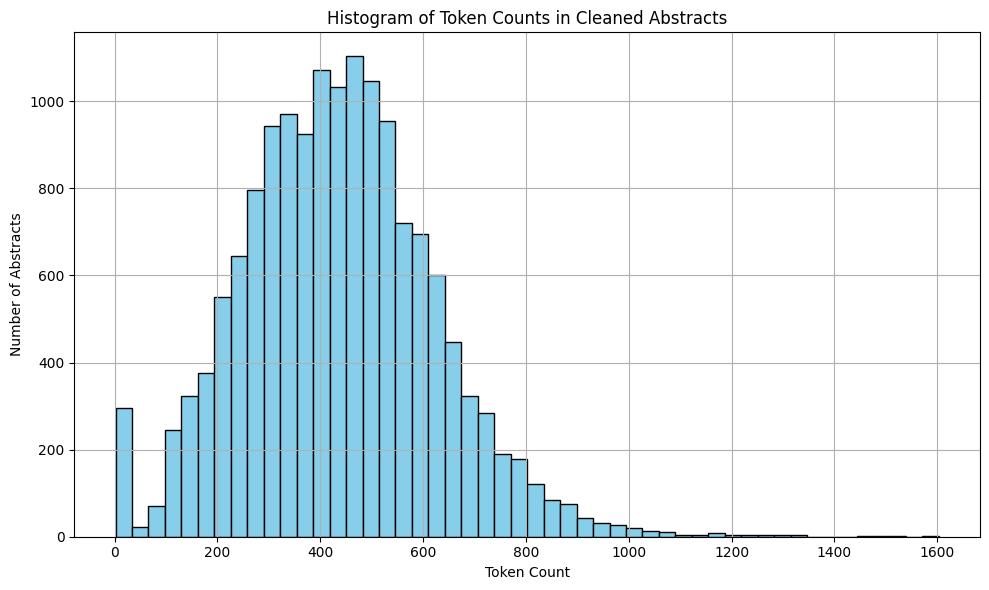

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import re

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-large-uncased", use_fast=True)

# Define abstract cleaning function
def clean_abstract(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    match = re.search(r'Technical Abstract\s*(.*?)(?:Non-technical Abstract|$)', text, re.DOTALL | re.IGNORECASE)
    if match:
        text = match.group(1).strip()
    text = re.sub(r'This award reflects NSF.*?review criteria\.', '', text, flags=re.IGNORECASE | re.DOTALL)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Clean abstracts
df['cleaned_abstract'] = df['awd_abstract_narration'].apply(clean_abstract)

# Compute token counts
token_counts = df['cleaned_abstract'].apply(lambda x: len(tokenizer.encode(x, truncation=False)))

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(token_counts, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Token Counts in Cleaned Abstracts')
plt.xlabel('Token Count')
plt.ylabel('Number of Abstracts')
plt.grid(True)
plt.tight_layout()
plt.show()


## USE 10 PERCENT FOR PROTYPTE

In [ ]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer


# Sample 10% of the data (stratified on citation label)
df_small = award_level_df.groupby('has_citations', group_keys=False).apply(lambda x: x.sample(frac=0.10, random_state=42)).reset_index(drop=True)

df = df_small.copy()

def preprocess_text(row):
    #meta = f"Directorate: {row['org_dir_long_name']} | Division: {row['org_div_long_name']} | Start: {row['awd_eff_date']} | End: {row['awd_exp_date']}"
    #return f"{meta} [SEP] {row['awd_abstract_narration']}"
    return f"{row['awd_abstract_narration']}"

df['bert_input'] = df.apply(preprocess_text, axis=1)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['bert_input'].tolist(),
    df['has_citations'].tolist(),
    test_size=0.3,
    random_state=42,
    stratify=df['has_citations']
)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=512)



/tmp/ipython-input-30-3684773765.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_small = award_level_df.groupby('has_citations', group_keys=False).apply(lambda x: x.sample(frac=0.10, random_state=42)).reset_index(drop=True)


In [ ]:
for i in range(5):
    print(f"\nSample {i+1}")
    print(df.iloc[i]['bert_input'])


Sample 1
Technical Abstract
The acquisition of an atomic force microscope (AFM) will allow multiple users within the science and engineering departments at Bucknell University, a predominantly undergraduate institution, to incorporate modern surface analysis into a wide variety of research projects.  The ability of AFM to image the topography of a sample on the nanoscale will be utilized to investigate important environmental and industrial processes. Specific research projects include (but are not limited to): 1.) studies of the chemical and physical properties of redox-active clay minerals and the changes that accompany reduction and oxidation of iron species; 2.) determination of the effects of the chemical and physical properties of organic aerosol particles on the uptake of water vapor; and 3.) correlation of the physical changes in photoresists with chemical phenomena in order to better understand the effects of different processing parameters used in immersion lithography.  Wit

In [ ]:
df['has_citations'].value_counts(dropna=False)

,count
has_citations,
1,6795
0,1482


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch

# Compute weights: assumes target labels are 0 and 1
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=train_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Class Weights:", class_weights)


Class Weights: [2.79315333 0.60902019]


In [ ]:
from transformers import BertForSequenceClassification
import torch.nn as nn

class WeightedBertForSequenceClassification(BertForSequenceClassification):
    def __init__(self, config, class_weights):
        super().__init__(config)
        self.class_weights = class_weights

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, **kwargs):
        outputs = super().forward(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            output_hidden_states=False,
            return_dict=True
        )
        logits = outputs.logits
        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            loss = loss_fn(logits, labels)
        return {"loss": loss, "logits": logits}


In [ ]:
class BinaryCitationDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = BinaryCitationDataset(train_encodings, train_labels)
val_dataset = BinaryCitationDataset(val_encodings, val_labels)



In [ ]:
from transformers import AutoConfig, Trainer, TrainingArguments

config = AutoConfig.from_pretrained("bert-large-uncased", num_labels=2)
model = WeightedBertForSequenceClassification.from_pretrained(
    "bert-large-uncased",
    config=config,
    class_weights=class_weights_tensor
)

training_args = TrainingArguments(
    output_dir="./results_binary",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir='./logs'
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    report_to = 'wandb'

)
trainer.train()



Some weights of WeightedBertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
500,0.700000
1000,0.646700


TrainOutput(global_step=1089, training_loss=0.6666764994079197, metrics={'train_runtime': 1100.4279, 'train_samples_per_second': 15.793, 'train_steps_per_second': 0.99, 'total_flos': 1.6196035163277312e+16, 'train_loss': 0.6666764994079197, 'epoch': 3.0})

In [ ]:
preds = trainer.predict(val_dataset)
predicted_class = np.argmax(preds.predictions, axis=1)

from sklearn.metrics import classification_report
print(classification_report(val_labels, predicted_class))


              precision    recall  f1-score   support

           0       0.23      0.36      0.28       445
           1       0.84      0.73      0.78      2039

    accuracy                           0.67      2484
   macro avg       0.54      0.55      0.53      2484
weighted avg       0.73      0.67      0.69      2484



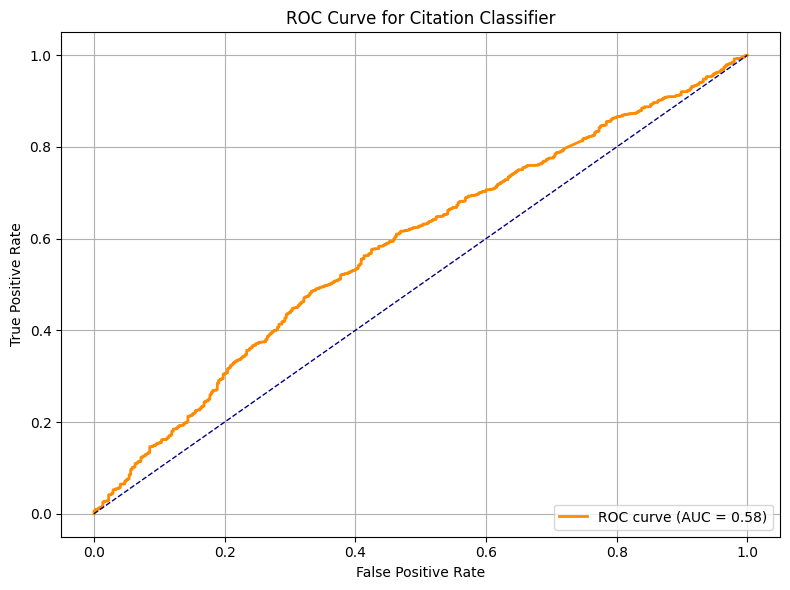

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction logits from validation set
predictions = trainer.predict(val_dataset)
logits = predictions.predictions
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1).numpy()
positive_probs = probs[:, 1]  # Probability of class 1 (has citation)

# True labels
y_true = np.array(val_labels)

fpr, tpr, thresholds = roc_curve(y_true, positive_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Citation Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()

